### Load Data

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def generate_data(n, r, inv=False):
    x = list(range(-n//2, n//2))
    if inv:
        y = [n-random.randint(i-r, i+r) for i in x]
    else:
        y = [random.randint(i-r, i+r) for i in x]
    plt.scatter(x, y)
    plt.grid()
    plt.show()
    return np.array(x), np.array(y)

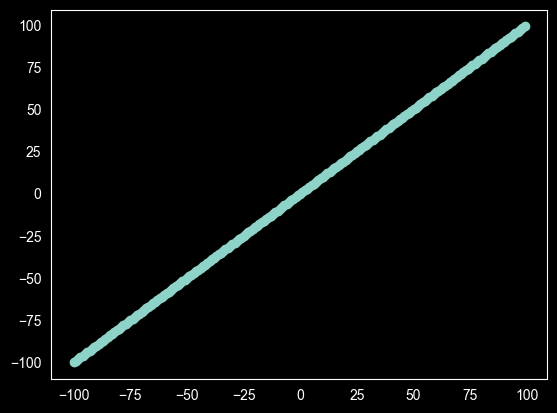

In [2]:
# Data 1
n = 200
r = 0
x1, y1 = generate_data(n, r)

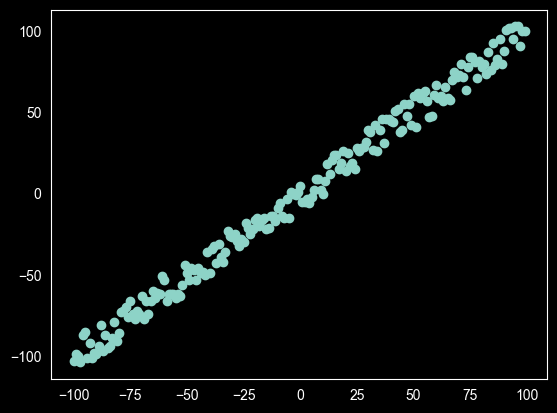

In [3]:
# Data 2
n = 200
r = 10
x2, y2 = generate_data(n, r)

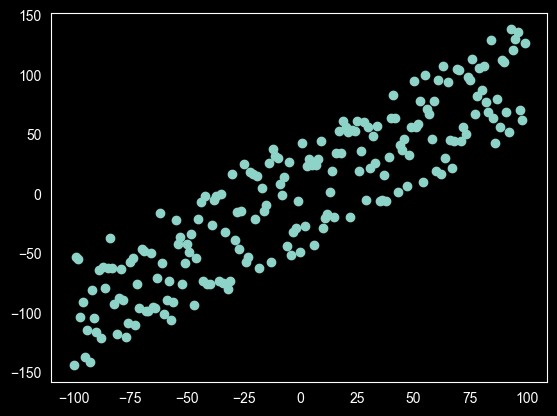

In [4]:
# Data 3
n = 200
r = 50
x3, y3 = generate_data(n, r)

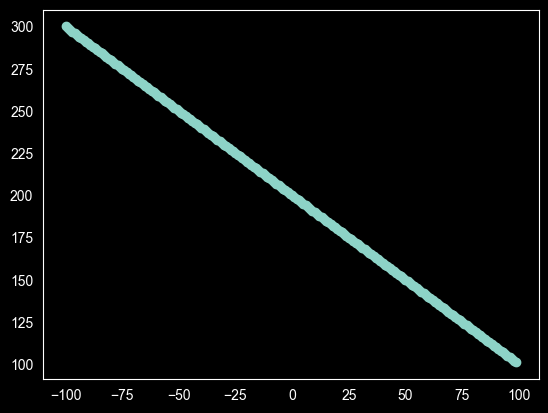

In [5]:
# Data 4
n = 200
r = 0
x4, y4 = generate_data(n, r, inv=True)

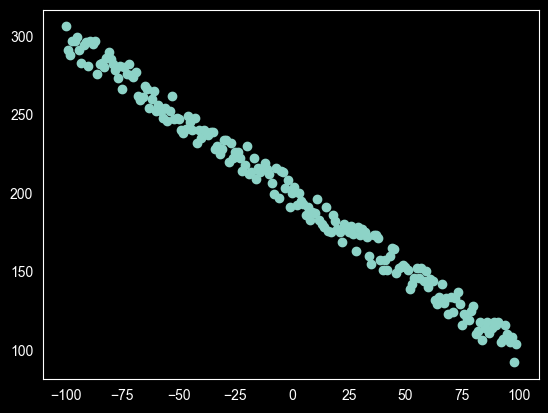

In [6]:
# Data 5
n = 200
r = 10
x5, y5 = generate_data(n, r, inv=True)

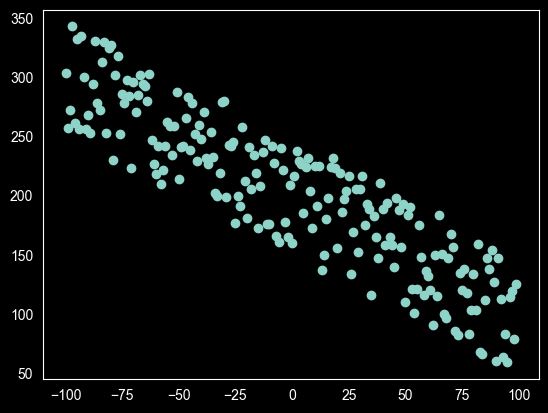

In [7]:
# Data 6
n = 200
r = 50
x6, y6 = generate_data(n, r, inv=True)

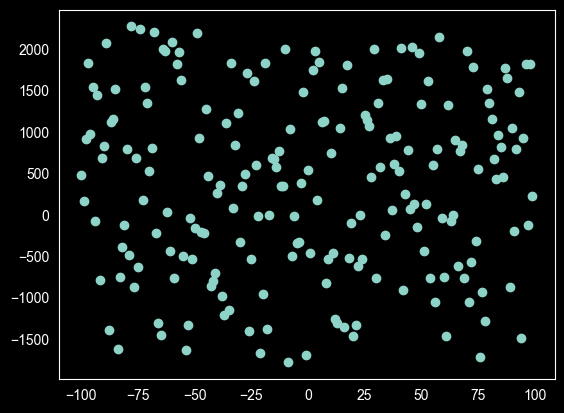

In [8]:
# Data 7
n = 200
r = 2000
x7, y7 = generate_data(n, r, inv=True)

### Utils

In [9]:
def predict(x, m, c):
    return m*x + c

In [10]:
def mse(y, y_pred):
    n = len(y)
    sse = 0
    error = y_pred - y
    se = error**2
    sse = sum(se)
    mse = sse/n
    return round(mse, 4)

In [11]:
def r2(y, y_pred):
    y_mean = np.mean(y)
    return round(1 - sum((y-y_pred)**2)/sum((y-y_mean)**2), 4)


In [12]:
def plot(x, y, m, c):
    plt.scatter(x, y)
    plt.plot(x, [m*i+c for i in x], "r")
    plt.grid()
    plt.show()

### Solve by Normal Equation

In [13]:
# Lasso Has no Closed form Solution in Matrix Notation

### Solve by SVD

In [14]:
# Lasso Cant be done by SVD without Iterative method

### Solve by Grid Search

In [15]:
def solve_by_grid_search(x, y, alpha=1000):
    best_b0 = None
    best_b1 = None
    best_loss = float("inf")
    for b0 in range(-20, 2100):
        for b1 in range(-10, 11):
            b00 = b0 / 10
            b11 = b1 / 10
            predictions = []
            for xi in x:
                y_hat = b00 + b11 * xi
                predictions.append(y_hat)
            squared_errors = []
            for yi, y_hat in zip(y, predictions):
                squared_errors.append((yi - y_hat) ** 2)
            mse_ = sum(squared_errors) / len(y)
            lasso_penalty = alpha * abs(b11)
            loss = mse_ + lasso_penalty
            if loss < best_loss:
                best_loss = loss
                best_b0 = b00
                best_b1 = b11
    c = best_b0
    m = best_b1
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(
        f"Slope :", m,
        "  y-Intercept :", c,
        "  MSE :", MSE,
        "  R2 :", R2,
        "  Lasso Loss :", best_loss
    )
    plot(x, y, m, c)

Slope : 0.8   y-Intercept : -0.1   MSE : 133.33   R2 : 0.96   Lasso Loss : 933.3299999999999


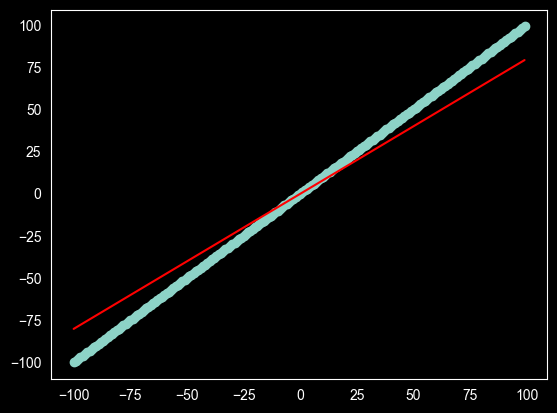

In [16]:
# Solve for Data 1
solve_by_grid_search(x1, y1)

Slope : 0.9   y-Intercept : -0.2   MSE : 84.203   R2 : 0.976   Lasso Loss : 984.203


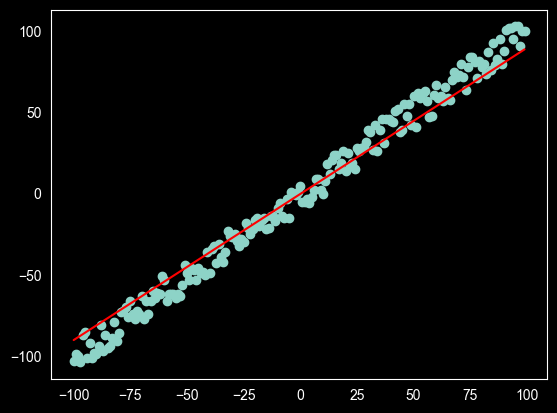

In [17]:
# Solve for Data 2
solve_by_grid_search(x2, y2)

Slope : 0.9   y-Intercept : 0.0   MSE : 951.402   R2 : 0.789   Lasso Loss : 1851.4019999999998


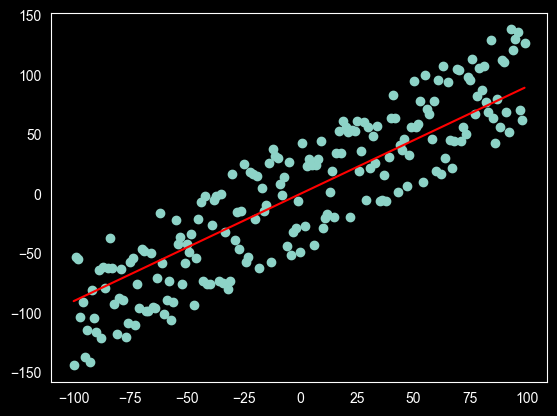

In [18]:
# Solve for Data 3
solve_by_grid_search(x3, y3)

Slope : 0.9   y-Intercept : 0.0   MSE : 951.402   R2 : 0.789   Lasso Loss : 1851.4019999999998


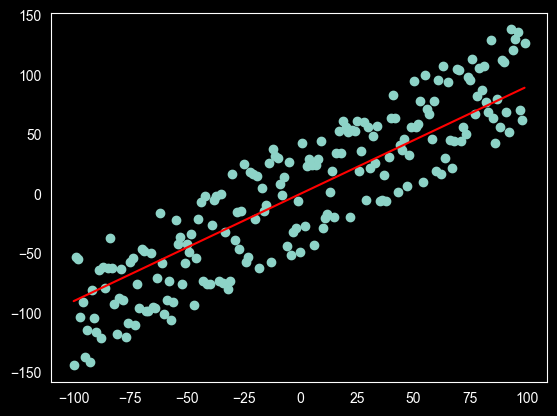

In [19]:
# Solve for Data 3
solve_by_grid_search(x3, y3)

Slope : -0.8   y-Intercept : 199.9   MSE : 153.722   R2 : 0.9534   Lasso Loss : 953.722


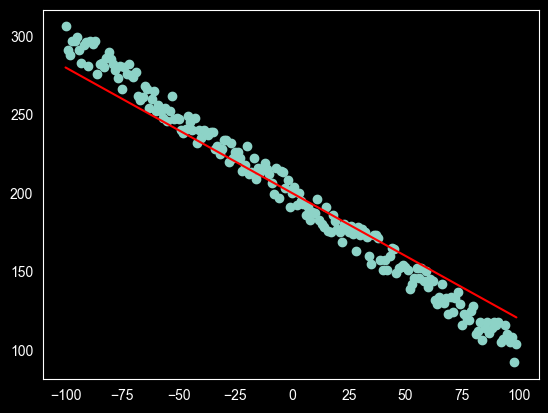

In [20]:
# Solve for Data 5
solve_by_grid_search(x5, y5)

Slope : -0.9   y-Intercept : 202.5   MSE : 926.505   R2 : 0.7837   Lasso Loss : 1826.505


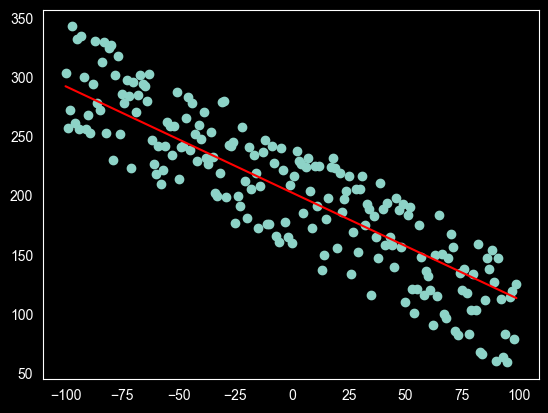

In [21]:
# Solve for Data 6
solve_by_grid_search(x6, y6)

Slope : 0.0   y-Intercept : 209.9   MSE : 1191066.644   R2 : -0.0205   Lasso Loss : 1191066.6440000015


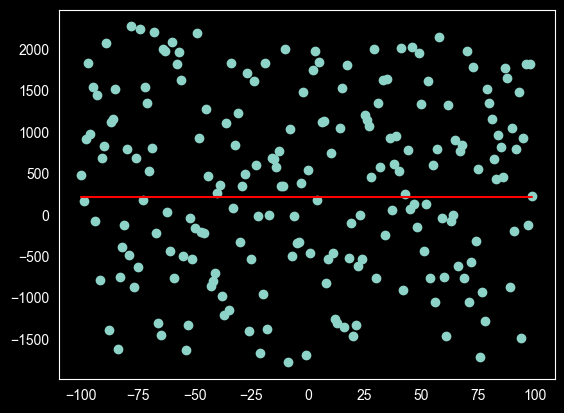

In [22]:
# Solve for Data 7
solve_by_grid_search(x7, y7)

### Solve by Gradient Descent

In [23]:
def solve_by_grad_descent(x, y, n_epochs=300, eta=0.1, lmbda=1):
    x_scaled = (x - x.mean()) / x.std()
    y_scaled = (y - y.mean()) / y.std()
    x_b = np.array([[1, i] for i in x_scaled])
    theta = np.array([0, 0]).reshape(-1, 1)
    n = len(x_b)
    y_scaled = y_scaled.reshape(-1, 1)
    for epoch in range(n_epochs):
        gradients = 2 / n * x_b.T @ (x_b @ theta - y_scaled)
        lasso_gradient = lmbda * np.sign(theta)
        lasso_gradient[0] = 0 # Don't regularize intercept
        gradients += lasso_gradient
        theta = theta - eta * gradients
    c_scaled = theta[0][0]
    m_scaled = theta[1][0]
    m = m_scaled * y.std() / x.std()
    c = (c_scaled * y.std() + y.mean() - m * x.mean())
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope : {round(m, 4)}"
        f"  y-Intercept : {round(c, 4)}"
        f"  MSE : {MSE}"
        f"  R2 : {R2}")
    plot(x, y, m, c)

Slope : 0.5  y-Intercept : -0.25  MSE : 833.3125  R2 : 0.75


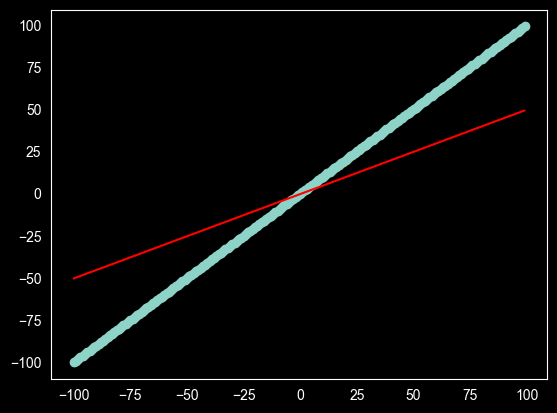

In [24]:
# Solve for Data 1
solve_by_grad_descent(x1, y1)

Slope : 0.5079  y-Intercept : -0.4311  MSE : 912.8651  R2 : 0.7399


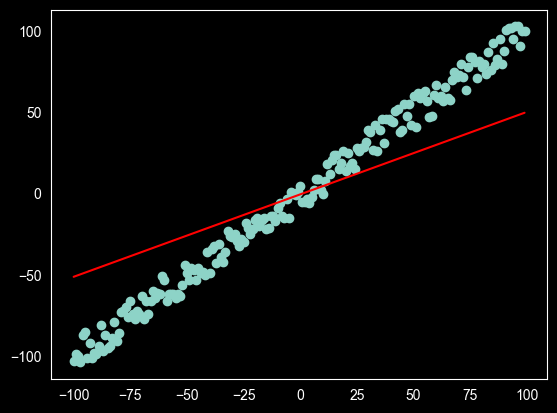

In [25]:
# Solve for Data 2
solve_by_grad_descent(x2, y2)

Slope : 0.4615  y-Intercept : -0.1993  MSE : 2010.5911  R2 : 0.5541


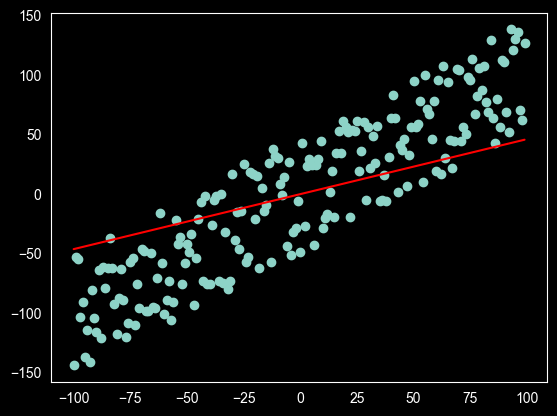

In [26]:
# Solve for Data 3
solve_by_grad_descent(x3, y3)

Slope : -0.5  y-Intercept : 200.25  MSE : 833.3125  R2 : 0.75


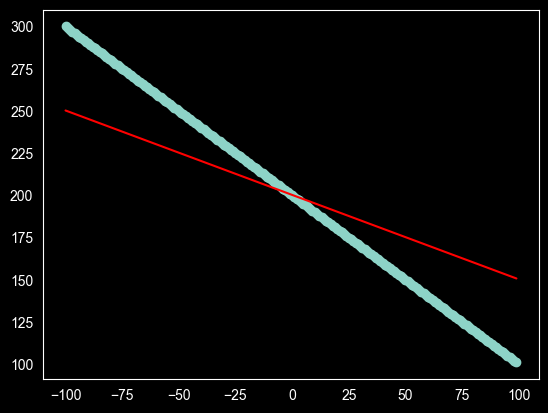

In [27]:
# Solve for Data 4
solve_by_grad_descent(x4, y4)

Slope : -0.492  y-Intercept : 200.024  MSE : 858.4128  R2 : 0.7396


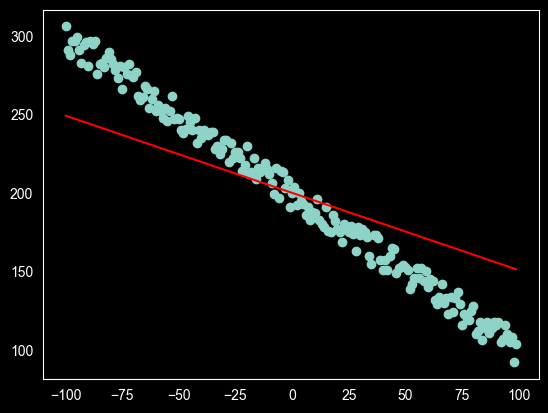

In [28]:
# Solve for Data 5
solve_by_grad_descent(x5, y5)

Slope : -0.4427  y-Intercept : 202.7587  MSE : 1957.3797  R2 : 0.543


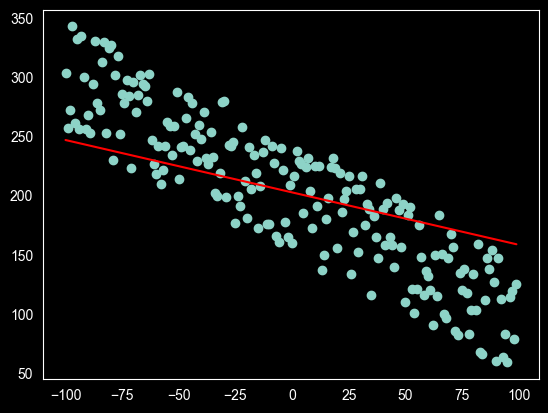

In [29]:
# Solve for Data 6
solve_by_grad_descent(x6, y6)

Slope : -0.9009  y-Intercept : 364.0196  MSE : 1170713.0351  R2 : -0.003


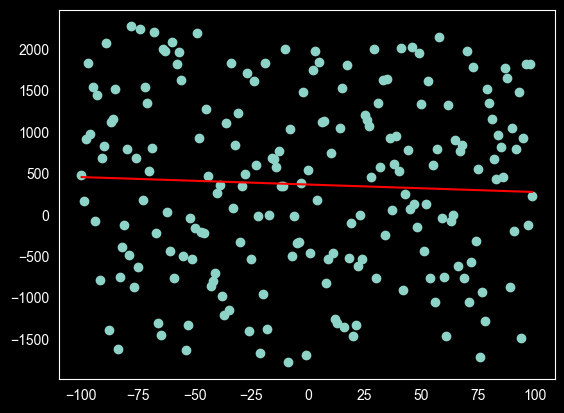

In [30]:
# Solve for Data 7
solve_by_grad_descent(x7, y7)

### Solve by SkLearn

In [31]:
from sklearn.linear_model import Lasso

def get_model(X, y):
    model = Lasso(alpha=1000)
    model.fit(X, y)
    return model.intercept_, model.coef_, model

In [32]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import add_dummy_feature

def solve_by_sklearn(x, y):
    x_b = x.reshape(-1, 1)
    c, m, model = get_model(x_b, y)
    y_pred = model.predict(x_b)
    MSE = mean_squared_error(y, y_pred)
    R2 = r2_score(y, y_pred)
    print(f"Slope :", m, "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plot(x, y, m, c)


Slope : [0.6999925]   y-Intercept : -0.15   MSE : 300.0075001875046   R2 : 0.9099954998312444


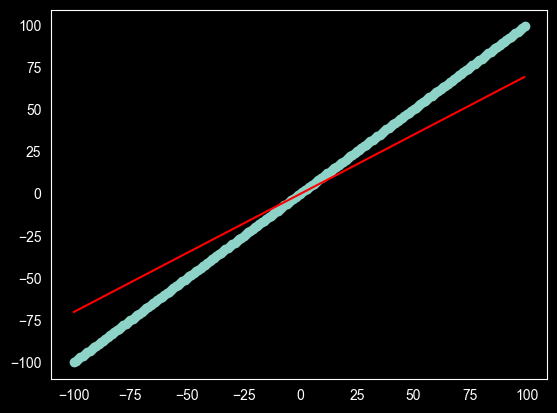

In [33]:
# Solve for Data 1
solve_by_sklearn(x1, y1)

Slope : [0.72090077]   y-Intercept : -0.3245   MSE : 335.48112539188486   R2 : 0.9044095062182201


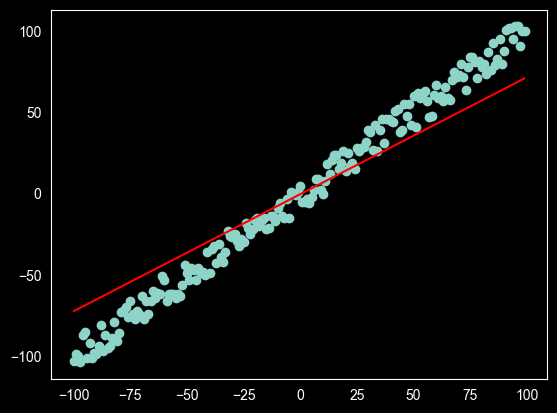

In [34]:
# Solve for Data 2
solve_by_sklearn(x2, y2)

Slope : [0.74303458]   y-Intercept : -0.0585   MSE : 1183.2073535363386   R2 : 0.737622735829595


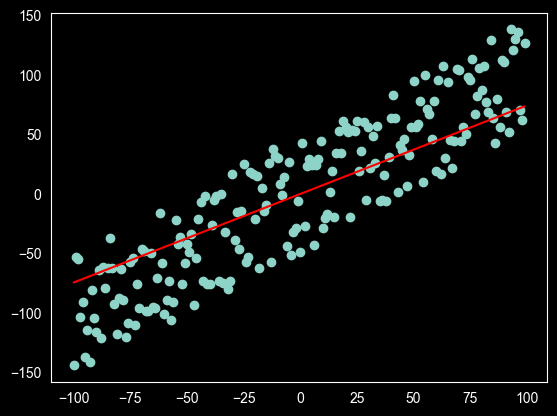

In [35]:
# Solve for Data 3
solve_by_sklearn(x3, y3)

Slope : [-0.6999925]   y-Intercept : 200.15   MSE : 300.0075001875046   R2 : 0.9099954998312444


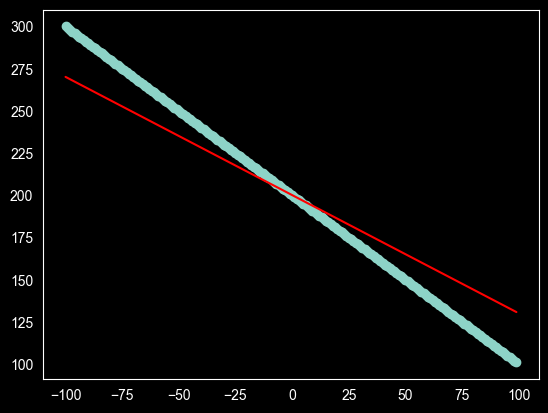

In [36]:
# Solve for Data 4
solve_by_sklearn(x4, y4)

Slope : [-0.68919523]   y-Intercept : 199.9254   MSE : 334.4060064426612   R2 : 0.8985436246105503


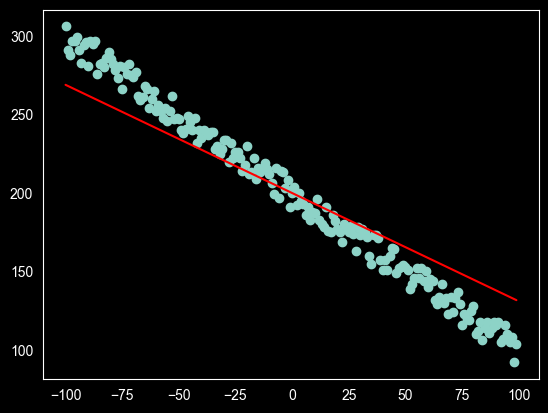

In [37]:
# Solve for Data 5
solve_by_sklearn(x5, y5)

Slope : [-0.70947574]   y-Intercept : 202.6253   MSE : 1186.5573350633765   R2 : 0.7229818351487531


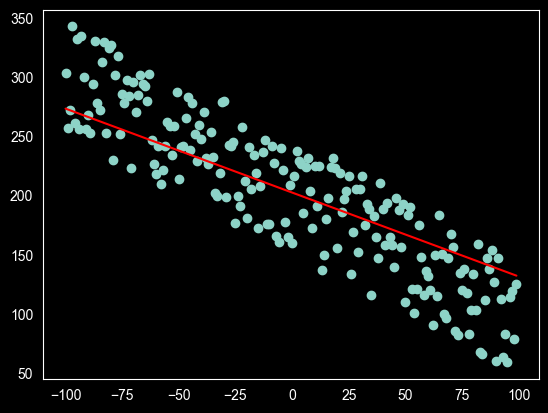

In [38]:
# Solve for Data 6
solve_by_sklearn(x6, y6)

Slope : [0.]   y-Intercept : 364.47   MSE : 1167174.7591   R2 : 0.0


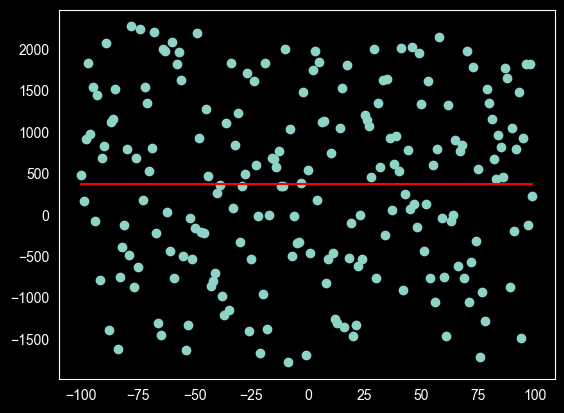

In [39]:
# Solve for Data 7
solve_by_sklearn(x7, y7)